# Study 04 · Predicting the station 02 inclination

Study 01 decided which recorded values are measurements and exported the
verdict-aware archive. Its final inclination product — compensated, anchored
once across the whole record, cleaned of impulsive noise, and flagged wherever
a value was interpolated rather than measured — is the only inclination series
this study uses.

The subject is one sensor at one place: the inclinometer at station 02. The
question is operational. Given the record as it actually stands, can the next
inclination value be predicted — from the inclination's own history, from the
other variables the package on the structure measures beside it, or from
external environmental proxies?

The archive carries a 271-day outage ending on 20 June 2023. This study works
only on what follows it, the stretch closest to the present and the only one
over which the complete instrument package exists. That window is not
continuous either, so the study proceeds in four movements:

1. Look at the window whole — every on-structure variable on one clock, with
   the gaps left as gaps.
2. Inventory the gaps, classifying the missing time by duration.
3. Weigh the ways each class of gap might be filled.
4. Put the prediction question to the on-structure measurements, the external
   proxies, or both.

Movements 2 to 4 are being rebuilt to the design in
docs/superpowers/specs/2026-08-25-study04-decomposition-and-anomaly-design.md.
The previous experiment's cells were removed rather than held inert; its
reusable logic survives in shmlib.prediction.

## Imports and parameters

All library operations live in `shmlib`. This notebook owns the data
pointers and the choices that make this one experiment: the response channel,
the window, and the variables drawn from the on-structure package.

In [1]:
import logging
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

from shmlib import adc, figures, prediction, proxies, site, tables, viz

warnings.filterwarnings('ignore')
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
viz.apply_report_style()

In [2]:
# ---------------------------------------------------------------------------
# Data pointers
# ---------------------------------------------------------------------------
ARCHIVE_CSV = '../../data/interim/archive/gubbio_archive_20min.csv'
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------------------------
# Grids
# ---------------------------------------------------------------------------
# The archive is written every twenty minutes and this study reads it at that
# spacing, because that is the rate at which a deployed system receives a new
# reading and therefore the rate at which it must judge one. Model A works on
# this grid. Model B works hourly: measured on this record, the twenty-minute
# first difference has a lag-one autocorrelation of -0.058, the signature of
# measurement noise dominating the increment, while the hourly difference
# retains +0.349 of memory and couples to air temperature at -0.893 rather
# than -0.778. Notebook step 3 re-measures both and exports the comparison.
NATIVE_FREQ = '20min'
MODEL_FREQ_A = '20min'          # decomposition and expectation
MODEL_FREQ_B = '1h'             # forecast skill

# ---------------------------------------------------------------------------
# The response
# ---------------------------------------------------------------------------
# Study 01's final inclination product: compensated, anchored once across the
# whole record, and cleaned of impulsive noise. Read with honour_spike=True, so
# every value the cleaning interpolated is returned missing rather than as a
# measurement. No earlier or intermediate version of this channel is used.
TARGET_COLUMN = 'inc_comp_cleaned'

# No raw channel is read. Compensation is Study 01's discussion and this study
# is blind to it (D10): the compensated, cleaned channel above is the raw
# material here, and the sign contradiction of docs/raw-data-format.md section
# 7.5 stays Study 01's open question.

# ---------------------------------------------------------------------------
# The window
# ---------------------------------------------------------------------------
# The archive carries a 271-day outage beginning 2022-09-23 whose last missing
# day is 2023-06-20. This study starts on the day after it and runs to the end
# of the archive: the stretch closest to the present, and the one a system
# deployed today would have to work with.
SEGMENT_START = '2023-06-21'

# ---------------------------------------------------------------------------
# Predictors
# ---------------------------------------------------------------------------
# Air temperature and relative humidity only. Measured on this record, their
# missingness is perfectly nested inside the inclination's, so they cost no
# coverage at all: requiring them leaves the same complete rows in the same
# segments. Wall temperature and solar radiation are excluded from every model
# by design decision D11 - requiring them collapses coverage from 75.6% to
# 17.0%. They are still loaded and still drawn in the record figure below,
# because what the package records is part of what this study has to describe,
# and the reader is owed the sight of the two channels the study set aside.
PREDICTOR_COLUMNS = ('tair', 'rh')

# Battery voltage is carried as the negative control only. Study 03 established
# that it is not a silent channel - it reaches r = -0.673 in the diurnal band -
# so it marks a conservative floor rather than a zero.
CONTROL_COLUMN = 'batt'

# ---------------------------------------------------------------------------
# Model A - decomposition and expectation
# ---------------------------------------------------------------------------
# Zero autoregressive lags. With n_lags > 0 the autoregressive component absorbs
# most of the diurnal structure, and the seasonal component becomes the
# periodicity left over after it rather than the wall's thermal cycle. A
# decomposition meant to be read as physics must therefore carry no AR term.
MODEL_A_LAGS = 0

# Two fits, because one model cannot do both jobs on this record.
#
# The attribution fit carries a piecewise-linear trend: the drift is the
# structurally interesting component and does not exist under growth='off'.
# Its numbers are read in-sample, where a fitted trend is constrained by data.
MODEL_A_GROWTH = 'linear'

# The monitoring fit carries no trend at all. Measured on this record, a
# piecewise-linear trend extrapolated past its last changepoint dominates
# everything downstream: over the evaluation stretch the residual of the
# attribution fit has a standard deviation of 41.9 mdeg and reaches -194,
# against 13.8 and -43 for the same model without the trend. A control chart
# calibrated on the first would spend its entire alarm budget on the model's
# own extrapolation error. Dropping the trend leaves the drift inside the
# residual, which is the right place for it: a monitoring system should watch
# a drift, not have it subtracted away before it looks.
MODEL_A_MONITOR_GROWTH = 'off'

# Changepoints are placed at quantiles of the observed timestamps rather than
# uniformly along the axis: this window contains outages of 40, 42, 17 and 103
# days, and a changepoint inside one is constrained by no data.
MODEL_A_CHANGEPOINTS = 12

# Yearly seasonality is fitted both ways, because the comparison is worth
# reporting: the window spans 3.2 annual cycles with a 103-day hole in the last
# one, which is not obviously enough to identify an annual term, and on this
# record the annual term costs held-out accuracy rather than buying it.
MODEL_A_YEARLY_CANDIDATES = (False, True)

# The annual term is kept regardless of that comparison. Model A exists to
# attribute variation to named causes, not to minimise a forecast error, and the
# two goals disagree here. Without the term the residual carries a slow arch of
# about 75 mdeg peak to trough - the annual cycle itself - and everything
# downstream reads the residual as evidence of structural departure. A detector
# calibrated on it would spend its alarm budget on the seasons and could not see
# a millidegree-scale movement underneath. Leaving a known cause unmodelled to
# buy held-out accuracy would be buying the wrong thing.
MODEL_A_YEARLY = True

# Ljung-Box lags for the residual diagnostics: one slot, one day, three days.
RESIDUAL_LAGS = (1, 72, 216)

# Nominal miss rate of the interval, used by the Winkler interval score. It must
# match MODEL_A_QUANTILES above: change both together or the score stops being
# comparable with the coverage reported beside it.
NOWCAST_INTERVAL_ALPHA = 0.10

# The stretch drawn in the observed-against-expected figure. One month, chosen
# for readability rather than for flattery: it sits inside the evaluation period
# and carries both complete days and dropouts.
NOWCAST_VIEW = ('2025-11-01', '2025-12-01')

# The stretch drawn in the daily-cycle figure. A fortnight, short enough that
# individual cycles are legible.
COMPONENT_VIEW = ('2025-11-01', '2025-11-15')

# ---------------------------------------------------------------------------
# The rolling expectation
# ---------------------------------------------------------------------------
# How often the monitoring model is refitted, and how much history it must have
# before it is allowed to speak. A frozen fit is not a monitoring system: fitted
# once to 2025-09 and applied afterwards, this model sits 28.75 mdeg away from
# the record, and 82% of its mean square error is that constant offset rather
# than scatter. Refitting monthly holds the expectation to within the drift a
# month can accumulate, which at the measured -2.77 mdeg/yr is about 0.23 mdeg.
ROLLING_REFIT_EVERY = '30d'

# A window must hold at least one full annual cycle before it is allowed to
# speak, because the model carries an annual term and a term fitted to less than
# a cycle is unidentifiable: it can take any amplitude and phase that flatters
# the months it happens to see. At 180 days the early windows did exactly that,
# and their residuals both dragged the average and fattened the tails the
# conformal interval calibrates on.
ROLLING_MIN_TRAIN = '365d'

# Where the conformal interval is calibrated. Residual quantiles are taken at or
# before this instant and applied everywhere, so no row is ever judged against
# an interval calibrated on itself. It matches the reference window that step 7
# calibrates its control charts on, for the same reason.
CONFORMAL_CALIBRATION_END = '2025-06-01'

MODEL_A_EPOCHS = 30
MODEL_A_QUANTILES = (0.05, 0.95)
MODEL_A_SEED = 0

# Training origin: the model is fitted on everything before this instant and
# judged on everything after it. Chronological, never random.
MODEL_A_TRAIN_END = '2025-09-01'

# Minimum segment length, in slots. A segment shorter than a day cannot inform
# a daily seasonality, and contributes noise to the trend.
MODEL_A_MIN_SEGMENT = 72

# ---------------------------------------------------------------------------
# Channel maps
# ---------------------------------------------------------------------------
# The archive names the package's channels differently before and after the
# instrument installed on 2025-02-21, so each set is loaded under its own map
# and the two are joined. This is a column-naming detail and not an analytical
# split: Study 01 already compensated and anchored the inclination once across
# the whole record, and no era offset is estimated anywhere in this study.
STR_MAP_CURRENT = {
    'tair': 'tair',
    'sr': 'n_sr_ok',
    'twall': 'n_twall_filtered',
    'rh': 'n_rh_ok',
    'batt': 'n_batt_ok',
}
STR_MAP_LEGACY = {
    'tair': 'tair',
    'rh': f'{site.TARGET_STATION}_rh_ok',
    'batt': f'{site.TARGET_STATION}_batt_ok',
}

# Panels of the record figure, response first, then the thermal channels, then
# the rest. Supply voltage is instrument housekeeping rather than a measurement
# of the wall or its environment, and is not drawn.
ON_STRUCTURE_COLUMNS = (
    TARGET_COLUMN, 'twall_str', 'tair_str', 'sr_str', 'rh_str')

# ---------------------------------------------------------------------------
# Gap anatomy and segmentation
# ---------------------------------------------------------------------------
# Autoregressive windows to evaluate against the record's contiguity, in hours.
# The chosen value is read off NP_03 in step 2 and set in step 6.
SURVIVAL_LAG_HOURS = (4, 8, 12, 24, 48)
SURVIVAL_FORECAST_HOURS = (8, 24)

## 1 · The window and the on-structure record

Both the response and the other channels of the package come from Study 01's
verdict-aware loaders: accepted values are kept and everything rejected or
absent stays missing. Radiation keeps its accepted values only, and wall
temperature uses the filtered probe channel Study 01 exported. Nothing is
interpolated here, and nothing is interpolated before drawing.

In [3]:
inclination, inclination_provenance = proxies.load_response(
    ARCHIVE_CSV, column=TARGET_COLUMN, honour_spike=True,
    freq=NATIVE_FREQ, tz=site.SITE_TZ, min_count=1)

sensor_current, sensor_provenance = proxies.load_sensor_forcings(
    ARCHIVE_CSV, column_map=STR_MAP_CURRENT, freq=NATIVE_FREQ,
    tz=site.SITE_TZ, honour_suspect=True, min_count=1)
sensor_legacy, _ = proxies.load_sensor_forcings(
    ARCHIVE_CSV, column_map=STR_MAP_LEGACY, freq=NATIVE_FREQ,
    tz=site.SITE_TZ, honour_suspect=True, min_count=1)
sensor = proxies.join_eras([sensor_current, sensor_legacy])

record = proxies.harmonise([sensor, inclination.to_frame()], freq=NATIVE_FREQ)
window = record.loc[site.to_utc(pd.DatetimeIndex([SEGMENT_START]))[0]:]

print(f'Window: {window.index.min()} to {window.index.max()} '
      f'({len(window):,} slots on the {NATIVE_FREQ} grid)')
print(f'First accepted inclination inside the window: '
      f'{window[TARGET_COLUMN].dropna().index.min()}')

# Coverage per channel over the window, which is what the report quotes. It
# counts accepted values against the slots of the window, and says nothing yet
# about how the missing time is distributed — that is the next movement.
coverage = pd.DataFrame({
    'accepted': window[list(ON_STRUCTURE_COLUMNS)].notna().sum(),
    'coverage': window[list(ON_STRUCTURE_COLUMNS)].notna().mean(),
})
coverage.index.name = 'channel'
display(coverage)

coverage.reset_index().to_csv(OUTPUT_DIR / 'NP_01_window_coverage.csv',
                              index=False)

Window: 2023-06-20 22:00:00 to 2026-08-20 22:00:00 (83,305 slots on the 20min grid)
First accepted inclination inside the window: 2023-06-21 12:00:00


,accepted,coverage
channel,,
inc_comp_cleaned,62931,0.755429
twall_str,14632,0.175644
tair_str,64830,0.778225
sr_str,15682,0.188248
rh_str,64830,0.778225


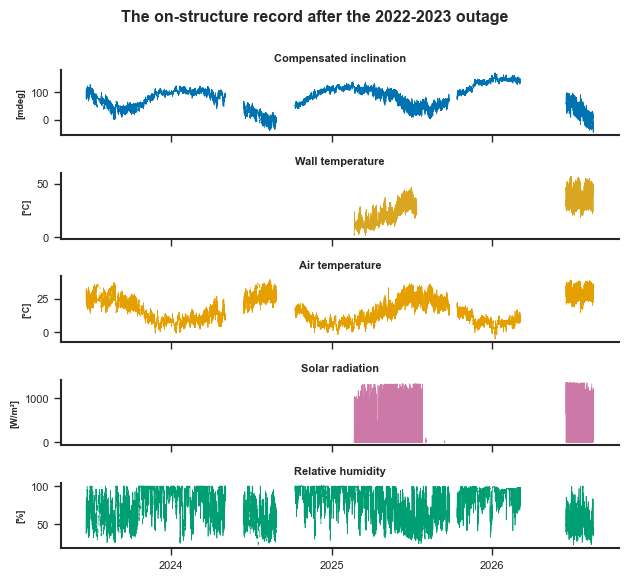

In [4]:
figures.plot_channel_panels(
    window, list(ON_STRUCTURE_COLUMNS),
    title='The on-structure record after the 2022-2023 outage',
    save_path=str(OUTPUT_DIR), filename='NP_F01_on_structure_record')
plt.show()

## 2 · The anatomy of what is missing

Study 01 measured how much of the record is absent and recorded explicitly
that it had not measured how that absence is *shaped*. It is measured here,
because the shape decides what kind of problem filling it is: recovering a
scattered sample from its immediate neighbours is a different proposition
from reconstructing a season. The same table also decides how long an
autoregressive window this record can afford, since a window can only be
trained inside a run of complete rows long enough to hold it.

### Parameter Tuning Guidance

**`SURVIVAL_LAG_HOURS`** — autoregressive window lengths to evaluate, in
hours. Accepts any increasing sequence of positive integers; default
`(4, 8, 12, 24, 48)`. Raising the largest value costs training windows
quadratically on a fragmented record: each configuration is reported so the
choice made in step 6 can be read off the table rather than assumed.

**`SURVIVAL_FORECAST_HOURS`** — forecast lengths to pair with each window;
default `(8, 24)`. A configuration survives only in segments at least
`lag + forecast` long, so this parameter and the one above trade against each
other and are reported jointly.

1,647 gaps, 6,791 missing hours


,gaps,hours
gap_class,,
1-6h,315,759.000000
6-24h,48,505.666667
<=1h,1280,583.000000
>7d,4,4943.666667


,lag_hours,forecast_hours,n_rows,coverage,n_segments,median_segment_h,max_segment_h,n_surviving,n_windows
0,4,8,62931,0.755429,1647,1.666667,263.333333,476,39411
1,4,24,62931,0.755429,1647,1.666667,263.333333,186,23978
2,8,8,62931,0.755429,1647,1.666667,263.333333,403,34092
3,8,24,62931,0.755429,1647,1.666667,263.333333,175,21810
4,12,8,62931,0.755429,1647,1.666667,263.333333,320,29657
5,12,24,62931,0.755429,1647,1.666667,263.333333,157,19793
6,24,8,62931,0.755429,1647,1.666667,263.333333,175,21810
7,24,24,62931,0.755429,1647,1.666667,263.333333,101,15000
8,48,8,62931,0.755429,1647,1.666667,263.333333,91,12717
9,48,24,62931,0.755429,1647,1.666667,263.333333,58,9092


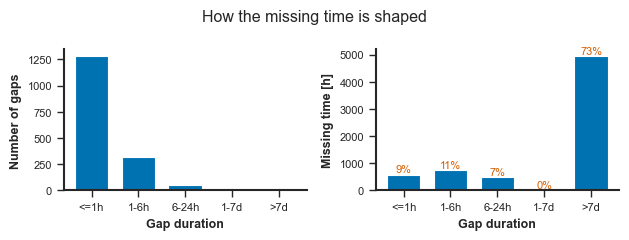

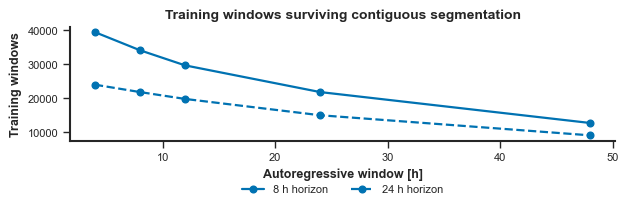

In [5]:
gaps = prediction.gap_inventory(window[TARGET_COLUMN], freq=NATIVE_FREQ)
print(f'{len(gaps):,} gaps, {gaps["duration_h"].sum():,.0f} missing hours')
display(gaps.groupby('gap_class')
        .agg(gaps=('n_slots', 'size'), hours=('duration_h', 'sum')))

survival = prediction.segment_survival(
    window.rename(columns={TARGET_COLUMN: 'y'}),
    required=['y'] + [f'{name}_str' for name in PREDICTOR_COLUMNS],
    lag_hours=list(SURVIVAL_LAG_HOURS),
    forecast_hours=list(SURVIVAL_FORECAST_HOURS),
    freq=NATIVE_FREQ)
display(survival)

gaps.to_csv(OUTPUT_DIR / 'NP_02_gap_inventory.csv', index=False)
survival.to_csv(OUTPUT_DIR / 'NP_03_segment_survival.csv', index=False)

figures.plot_gap_anatomy(
    gaps, title='How the missing time is shaped',
    save_path=str(OUTPUT_DIR), filename='NP_F02_gap_anatomy')
figures.plot_segment_survival(
    survival, title='Training windows surviving contiguous segmentation',
    save_path=str(OUTPUT_DIR), filename='NP_F03_segment_survival')
plt.show()

## 3 · Which cadence, and which target

Two choices are settled here by measurement rather than by preference: whether
the level or its first difference is the quantity to score, and at which
spacing. A level whose lag-one autocorrelation approaches unity cannot be
scored honestly, because any error metric computed against it measures the
sampling interval rather than the model. A first difference whose lag-one
autocorrelation is *negative* is dominated by measurement noise on the level
rather than by the increment it is meant to carry. Both quantities are
reported at both candidate cadences, together with the coupling to air
temperature and the drift each implies.

### Parameter Tuning Guidance

**`MODEL_FREQ_A`** — grid for the decomposition and expectation model;
default `'20min'`, the archive's native spacing and the rate at which a
deployed system receives a reading. The anomaly question does not require
differencing, so the noise that spoils the twenty-minute difference does not
affect it.

**`MODEL_FREQ_B`** — grid for the forecast model; default `'1h'`. Set it to
`'20min'` only if `NP_04` shows a non-negative change autocorrelation there;
on this record it does not.

,cadence,n_level,n_change,level_autocorr1,change_autocorr1,change_std,change_mad,corr_level,corr_change,drift_per_year
0,20min,62931,61284,0.997714,-0.058121,2.571814,0.78,-0.864658,-0.778051,-65.96587
1,1h,21747,21356,0.995387,0.349354,3.699914,1.30,-0.866470,-0.892439,2.30287


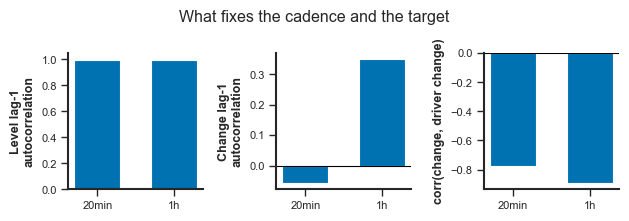

In [6]:
# No era label is passed (D9). Study 01 anchored the two instrument eras once,
# as a single series, and this study reads that product as its raw material;
# labelling the changeover here would only invite a second anchoring.
cadence = prediction.cadence_evidence(
    window[TARGET_COLUMN], window['tair_str'], era=None,
    cadences=(MODEL_FREQ_A, MODEL_FREQ_B), freq=NATIVE_FREQ)
display(cadence)

cadence.to_csv(OUTPUT_DIR / 'NP_04_cadence_evidence.csv', index=False)
figures.plot_cadence_evidence(
    cadence, title='What fixes the cadence and the target',
    save_path=str(OUTPUT_DIR), filename='NP_F04_cadence_evidence')
plt.show()

## 4 · What the record is made of

The level is decomposed into a trend, a daily cycle, the response to the two
environmental channels measured beside it, and a remainder. The level is used
here and nowhere else in this study: its lag-one autocorrelation is 0.998, so
an error metric computed against it would measure the sampling interval rather
than the model. What it is good for is the trend, which no differenced target
can recover — the mean of the gap-safe change implies −65.7 mdeg/yr at twenty
minutes and +0.97 mdeg/yr at one hour on this same record, because segment
endpoints do not sample the diurnal cycle uniformly.

Nothing is interpolated. Rows missing any required channel are dropped, the
remainder is split into contiguous segments, and each segment is handed to
NeuralProphet under its own identifier, so no fitted window ever spans a gap.
Imputation is disabled explicitly: with `impute_missing=True`, its default,
NeuralProphet silently fabricates gaps of at least thirty hours.

### Parameter Tuning Guidance

**`MODEL_A_LAGS`** — autoregressive lags; must stay `0`. Any positive value
transfers the diurnal cycle from the seasonal component into the
autoregressive one and makes the decomposition unreadable as physics.

**`MODEL_A_GROWTH`** — trend of the attribution fit; `'linear'` or `'off'`,
default `'linear'`. Under `'off'` the trend is a constant and the drift
disappears, which is why the attribution fit keeps it.

**`MODEL_A_MONITOR_GROWTH`** — trend of the monitoring fit; default `'off'`.
This is the fit whose residual becomes the expectation error of step 6 and the
control statistic of step 7. It carries no trend because an extrapolated one
is the largest error in the residual by a factor of three, and because the
drift belongs in front of the detector rather than behind it.

**`MODEL_A_CHANGEPOINTS`** — number of trend changepoints, placed on covered
time; default `12`, roughly one per quarter of the window. More changepoints
track shorter movements at the cost of absorbing signal that belongs to the
seasonal or regressor terms.

**`MODEL_A_YEARLY_CANDIDATES`** — which annual settings are fitted for the
comparison; both, so the cost of the annual term is measured and reported
rather than assumed.

**`MODEL_A_YEARLY`** — which of them is carried forward; default `True`. This
is deliberately not the held-out winner. Model A is read as an attribution of
variation to named causes, and an annual cycle left out of the model does not
cease to exist: it moves into the residual, where the control charts of step 7
would read it as a structural departure. Set it to `False` only for a study
whose purpose is forecast accuracy rather than attribution.

**`MODEL_A_TRAIN_END`** — the frozen training origin. Everything after it is
out of sample. Moving it later buys training data and costs evaluation data.

**`MODEL_A_MIN_SEGMENT`** — shortest usable run, in slots; default `72`, one
day at twenty minutes.

In [7]:
frame_a = (window.rename(columns={TARGET_COLUMN: 'y'})
           .rename(columns={f'{name}_str': name for name in PREDICTOR_COLUMNS})
           .loc[:, ['y'] + list(PREDICTOR_COLUMNS)])

segmented_a = prediction.contiguous_segments(
    frame_a, required=['y'] + list(PREDICTOR_COLUMNS),
    min_length=MODEL_A_MIN_SEGMENT, freq=MODEL_FREQ_A)

train_a = segmented_a.loc[:MODEL_A_TRAIN_END]
test_a = segmented_a.loc[MODEL_A_TRAIN_END:]
changepoints_a = prediction.covered_changepoints(
    train_a.index, MODEL_A_CHANGEPOINTS)

print(f'Model A: {len(train_a):,} training rows in '
      f'{train_a["segment_id"].nunique()} segments, '
      f'{len(test_a):,} evaluation rows')

Model A: 32,161 training rows in 166 segments, 9,920 evaluation rows


In [8]:
fits = {}
for yearly in MODEL_A_YEARLY_CANDIDATES:
    model, predictions = prediction.neuralprophet_backtest(
        train_a, test_a, regressors=PREDICTOR_COLUMNS, task='nowcast',
        n_lags=MODEL_A_LAGS, epochs=MODEL_A_EPOCHS, yearly=yearly,
        quantiles=MODEL_A_QUANTILES, seed=MODEL_A_SEED,
        growth=MODEL_A_GROWTH, changepoints=changepoints_a,
        freq=MODEL_FREQ_A)
    fits[yearly] = (model, predictions)
    scores = prediction.score_predictions(predictions, [])
    print(f'yearly={yearly}: out-of-sample MAE {scores["mae"].iloc[0]:.3f} mdeg')

# The held-out winner is reported, and then not obeyed: see MODEL_A_YEARLY.
mae_optimal = min(
    fits, key=lambda flag: prediction.score_predictions(
        fits[flag][1], [])['mae'].iloc[0])
model_a, predictions_a = fits[MODEL_A_YEARLY]
print(f'Lowest held-out MAE at yearly={mae_optimal}; '
      f'carried forward yearly={MODEL_A_YEARLY} '
      f'({"agrees" if mae_optimal == MODEL_A_YEARLY else "overridden for attribution"})')

Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.083% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 98.667% of the data.


...

INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.206% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.329% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


yearly=True: out-of-sample MAE 58.824 mdeg
Lowest held-out MAE at yearly=False; carried forward yearly=True (overridden for attribution)


In [9]:
# The monitoring fit: same data, same regressors, same annual term, no trend.
model_m, predictions_m = prediction.neuralprophet_backtest(
    train_a, test_a, regressors=PREDICTOR_COLUMNS, task='nowcast',
    n_lags=MODEL_A_LAGS, epochs=MODEL_A_EPOCHS, yearly=MODEL_A_YEARLY,
    quantiles=MODEL_A_QUANTILES, seed=MODEL_A_SEED,
    growth=MODEL_A_MONITOR_GROWTH, changepoints=None, n_changepoints=0,
    freq=MODEL_FREQ_A)
monitor_scores = prediction.score_predictions(predictions_m, [])
print(f'Monitoring fit (growth={MODEL_A_MONITOR_GROWTH!r}): '
      f'out-of-sample MAE {monitor_scores["mae"].iloc[0]:.3f} mdeg')

INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.083% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 98.667% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.115% of the data.


...

INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.206% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.329% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


Monitoring fit (growth='off'): out-of-sample MAE 30.586 mdeg


## 5 · The components, and whether they agree with Study 03

Two fits are carried from here, and they answer different questions. The
**attribution fit** keeps a piecewise-linear trend and says what the record is
made of; its trend is the study's drift estimate, and it is read over the
training window, where a fitted trend is constrained by observations. The
**monitoring fit** is the same model without that trend, and its residual is
what step 6 judges a new reading against and step 7 charts.

The split is forced by the record rather than chosen for elegance. Measured
over the evaluation stretch, the attribution fit's residual has a standard
deviation of 41.9 mdeg and reaches -194, against 13.8 and -43 for the same
model with no trend: past its last changepoint the trend is an extrapolation,
and on a record with a 103-day hole it is by far the largest error in the
residual. Monitoring on it would mean alarming on the model's own
extrapolation. Dropping the trend leaves the drift in the residual, which is
where a monitoring system should meet it.

The fitted air-temperature contribution is the one number in this study that
can be checked against an independent measurement. Study 03 screened the same
response against the same channel by a completely different method — a lag and
gain scan on the diurnal band — and measured **−2.79 mdeg/°C** with
`r = −0.957`, a value that survived substitution of the ground station
(−2.23) and ERA5 (−2.04) for the on-structure sensor. If this decomposition
reproduces it, two unrelated methods agree on a physical constant. If it does
not, that disagreement is the study's finding and the work stops here rather
than proceeding to build an anomaly detector on a model that does not describe
the wall.

The gain is fitted on the compensated channel, which this study takes as its
raw data. Whether Study 01's compensation is correctly sized is Study 01's
question, and it is not reopened here (D10): the number below is what the wall
does after that correction, which is the only quantity a monitoring system
ever sees.

INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.083% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 98.667% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.115% of the data.


...

INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.329% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


,component,variance,share,mean,peak_to_peak
0,trend,1867.075562,0.489381,137.989258,212.609146
1,residual,1160.056951,0.304064,-13.627974,241.530879
2,future_regressor_tair,464.289429,0.121695,-40.188183,108.228949
3,season_yearly,320.669495,0.084051,1.865707,63.589163
4,future_regressor_rh,1.848110,0.000484,3.661333,5.073369
5,season_daily,1.235111,0.000324,0.006016,4.153269


,fit,lag,lb_stat,lb_pvalue,n,std,mad
0,attribution,1,4.189906e+04,0.0,42014,34.060014,3.206351
1,attribution,72,2.907575e+06,0.0,42014,34.060014,3.206351
2,attribution,216,8.177538e+06,0.0,42014,34.060014,3.206351
3,"monitoring, frozen",1,4.168910e+04,0.0,42014,17.091348,5.026074
4,"monitoring, frozen",72,2.892008e+06,0.0,42014,17.091348,5.026074
5,"monitoring, frozen",216,8.323938e+06,0.0,42014,17.091348,5.026074


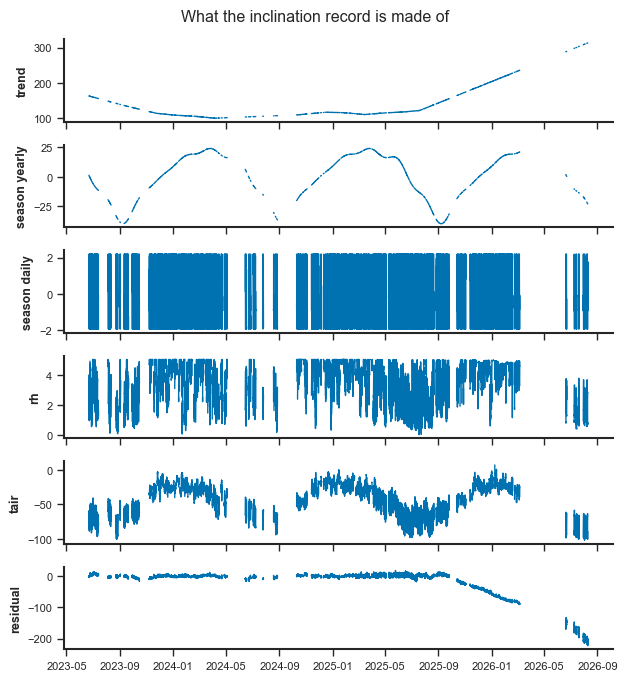

In [10]:
# The attribution fit says what the record is made of.
components_a = prediction.decompose_components(
    model_a, segmented_a, regressors=PREDICTOR_COLUMNS)

# The monitoring fit, whose residual step 6 refits on a schedule and then
# charts. Keeping the two apart is the whole point of fitting twice.
components_m = prediction.decompose_components(
    model_m, segmented_a, regressors=PREDICTOR_COLUMNS)

shares = prediction.component_variance_shares(components_a)
diagnostics = pd.concat([
    prediction.residual_diagnostics(
        components_a['residual'], lags=RESIDUAL_LAGS).assign(fit='attribution'),
    prediction.residual_diagnostics(
        components_m['residual'], lags=RESIDUAL_LAGS).assign(
            fit='monitoring, frozen'),
], ignore_index=True)
diagnostics = diagnostics[['fit'] + [c for c in diagnostics.columns
                                     if c != 'fit']]
display(shares)
display(diagnostics)

shares.to_csv(OUTPUT_DIR / 'NP_05_component_shares.csv', index=False)
diagnostics.to_csv(OUTPUT_DIR / 'NP_08_residual_diagnostics.csv', index=False)

# Drawn over the whole record, not merely the evaluation stretch. The annual
# term completes about three cycles here, and on the post-training window alone
# the 103-day outage falls exactly across a crest, which makes a fitted annual
# component look like a monotone ramp.
figures.plot_decomposition_stack(
    components_a, freq=MODEL_FREQ_A,
    title='What the inclination record is made of',
    save_path=str(OUTPUT_DIR), filename='NP_F05_decomposition_stack')
plt.show()

In [11]:
# The learned thermal gain, set against Study 03's three independent statements
# of it.
paired = pd.concat([components_a['future_regressor_tair'],
                    segmented_a['tair']], axis=1).dropna()
paired.columns = ['contribution', 'tair']
learned_gain = np.polyfit(paired['tair'], paired['contribution'], 1)[0]

gains = pd.DataFrame([
    {'source': 'Model A, compensated channel', 'gain_mdeg_per_degC': learned_gain,
     'method': 'NeuralProphet future regressor', 'n': len(paired)},
    {'source': 'Study 03, diurnal band', 'gain_mdeg_per_degC': -2.79,
     'method': 'lag and gain scan', 'n': np.nan},
    {'source': 'Study 03, ground station', 'gain_mdeg_per_degC': -2.23,
     'method': 'lag and gain scan', 'n': np.nan},
    {'source': 'Study 03, ERA5', 'gain_mdeg_per_degC': -2.04,
     'method': 'lag and gain scan', 'n': np.nan},
])
display(gains)
gains.to_csv(OUTPUT_DIR / 'NP_06_learned_gains.csv', index=False)

,source,gain_mdeg_per_degC,method,n
0,"Model A, compensated channel",-2.556791,NeuralProphet future regressor,42014.0
1,"Study 03, diurnal band",-2.790000,lag and gain scan,NaN
2,"Study 03, ground station",-2.230000,lag and gain scan,NaN
3,"Study 03, ERA5",-2.040000,lag and gain scan,NaN


In [12]:
# The drift, read from the attribution fit's trend over the training window
# only. Beyond the last changepoint the trend is an extrapolation and says
# nothing about the wall.
trend_in_sample = components_a['trend'].loc[:MODEL_A_TRAIN_END].dropna()
elapsed_days = ((trend_in_sample.index - trend_in_sample.index[0])
                / pd.Timedelta(days=1)).to_numpy()
drift_per_year = float(
    np.polyfit(elapsed_days, trend_in_sample.to_numpy(), 1)[0] * 365.0)
print(f'Fitted drift over the training window: {drift_per_year:+.2f} mdeg/yr '
      f'({trend_in_sample.index.min().date()} to '
      f'{trend_in_sample.index.max().date()})')

Fitted drift over the training window: -2.77 mdeg/yr (2023-06-21 to 2025-09-01)


## 6 · Is this reading the one that was expected?

The model is asked a conditional question, not a predictive one: given the air
temperature and relative humidity recorded in the same acquisition record as
this inclination, what inclination did the wall owe? Consuming those two
channels at the same instant is therefore not leakage — they arrive together,
twenty minutes at a time, and a monitoring system has them in hand at the
moment it must judge. The forecast model in step 8 is held to the opposite
rule and may consume only past predictor values; the two are never scored on
the same table.

The expectation is the monitoring fit's, not the attribution fit's, and it is
refitted on a schedule rather than frozen. Two measurements force both
choices. Past its last changepoint the attribution fit's trend is an
extrapolation, so an operator asking "is this reading normal" would be
answered mostly by how far that extrapolation has wandered. And a fit frozen
at the training origin goes stale: applied to the following year it sits
28.75 mdeg away from the record, with 82% of its mean square error in that
single offset rather than in scatter. Refitting every thirty days holds the
expectation to the drift a month can accumulate — about 0.23 mdeg at the
measured rate — which is what a deployed system does and what this study must
therefore report.

The interval is conformal rather than the model's own. NeuralProphet's
quantile regression fits the residual's core, and this residual has a tight
core with fat tails: its nominal 90% interval covers 68.7% even in-sample.
Empirical residual quantiles, calibrated on rows the interval is never scored
against, make coverage mean what it claims.

An interval that is drawn but never checked is decoration, so the 90 %
interval is scored on three counts: how often it actually contains the
observation, how wide it had to be to manage that, and the pinball loss of
each quantile on its own terms. Coverage alone can always be bought by
widening.

### Parameter Tuning Guidance

**`MODEL_A_QUANTILES`** — the interval's quantiles; default `(0.05, 0.95)`,
a nominal 90 % interval. Narrower quantiles alarm more often at a fixed
threshold and shorten detection delay at the cost of false alarms.

**`NOWCAST_INTERVAL_ALPHA`** — nominal miss rate used by the Winkler interval
score; default `0.10`, matching the quantiles above. Change both together or
the score is no longer comparable with the coverage beside it.

**`NOWCAST_VIEW`, `COMPONENT_VIEW`** — the stretches drawn in `NP_F07` and
`NP_F06`. They change what a reader sees and nothing that is computed.

**`ROLLING_REFIT_EVERY`** — how often the monitoring model is refitted;
default `'30d'`. Shorter keeps the expectation fresher and costs one fit per
window; longer lets the same staleness back in. This is the operational
parameter a deployment actually sets, and it is reported beside every number
derived from the rolling residual.

**`ROLLING_MIN_TRAIN`** — history required before the first window is scored;
default `'365d'`, one full annual cycle. It also decides where the usable
residual record begins, so raising it buys better early fits and costs months
of monitored record. Below a year the annual term is fitted to less than one
cycle and is not identifiable; the residuals of those windows are the widest
in the record and they contaminate whatever the conformal interval is
calibrated on.

**`CONFORMAL_CALIBRATION_END`** — the last instant whose residuals may inform
the interval; default `'2025-06-01'`. Rows after it are judged, never used to
calibrate what judges them.

In [13]:
# The naive scale for MASE is the in-sample mean absolute one-step change. It is
# computed on the training rows only: a scale taken from the evaluation rows
# would make the metric self-referential.
naive_scale_a = float(
    prediction.hourly_change(train_a['y'], freq=MODEL_FREQ_A).abs().mean())

# The rolling expectation: one fit per window, never more than
# ROLLING_REFIT_EVERY old, over the whole record rather than the held-out tail.
rolling_raw = prediction.rolling_nowcast(
    segmented_a, regressors=PREDICTOR_COLUMNS,
    refit_every=ROLLING_REFIT_EVERY, min_train=ROLLING_MIN_TRAIN,
    freq=MODEL_FREQ_A, n_lags=MODEL_A_LAGS, epochs=MODEL_A_EPOCHS,
    yearly=MODEL_A_YEARLY, quantiles=MODEL_A_QUANTILES, seed=MODEL_A_SEED,
    growth=MODEL_A_MONITOR_GROWTH, changepoints=None, n_changepoints=0)

rolling = prediction.conformal_interval(
    rolling_raw, alpha=NOWCAST_INTERVAL_ALPHA,
    calibration_end=CONFORMAL_CALIBRATION_END)

print(f'Rolling expectation: {len(rolling):,} rows from '
      f'{rolling["origin"].nunique()} refits, '
      f'{rolling["ds"].min().date()} to {rolling["ds"].max().date()}')

nowcast_scores = pd.concat([
    prediction.score_predictions(
        rolling, [], naive_scale=naive_scale_a,
        alpha=NOWCAST_INTERVAL_ALPHA).assign(fit='rolling, conformal'),
    prediction.score_predictions(
        predictions_m, [], naive_scale=naive_scale_a,
        alpha=NOWCAST_INTERVAL_ALPHA).assign(fit='frozen monitoring'),
    prediction.score_predictions(
        predictions_a, [], naive_scale=naive_scale_a,
        alpha=NOWCAST_INTERVAL_ALPHA).assign(fit='frozen attribution'),
], ignore_index=True)
nowcast_scores.insert(0, 'model', 'Model A · tair + rh')
nowcast_scores.insert(1, 'fit', nowcast_scores.pop('fit'))
display(nowcast_scores)
nowcast_scores.to_csv(OUTPUT_DIR / 'NP_07_nowcast_metrics.csv', index=False)

reported = nowcast_scores.iloc[0]
print(f'Rolling, conformal — nominal coverage '
      f'{1 - NOWCAST_INTERVAL_ALPHA:.0%}, observed '
      f'{reported["coverage_q05_q95"]:.1%}, median width '
      f'{reported["width_q05_q95"]:.2f} mdeg, MAE '
      f'{reported["mae"]:.2f} mdeg, bias {reported["bias"]:+.2f}, '
      f'MASE {reported["mase"]:.2f}')

# This residual, not the frozen fit's, is what step 7 charts and what every
# detectability number is quoted against.
residual_a = (rolling.set_index('ds')['y']
              - rolling.set_index('ds')['yhat']).dropna().sort_index()
print(f'Monitoring residual: {len(residual_a):,} slots, '
      f'sd {residual_a.std():.2f} mdeg, '
      f'MAD {float((residual_a - residual_a.median()).abs().median()):.2f}')

# NP_08 is rewritten here rather than in step 5, so that it describes the
# residual the study actually charts alongside the two frozen fits it is being
# preferred to.
diagnostics = pd.concat([
    prediction.residual_diagnostics(
        residual_a, lags=RESIDUAL_LAGS).assign(fit='rolling, conformal'),
    diagnostics,
], ignore_index=True)
diagnostics = diagnostics[['fit'] + [c for c in diagnostics.columns
                                     if c != 'fit']]
display(diagnostics)
diagnostics.to_csv(OUTPUT_DIR / 'NP_08_residual_diagnostics.csv', index=False)

INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.083% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 98.667% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.115% of the data.


...

INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


Rolling expectation: 28,400 rows from 24 refits, 2024-06-21 to 2026-08-09


,model,fit,n,mae,rmse,bias,r2,coverage_q05_q95,width_q05_q95,mase,pinball_q05,pinball_q95,interval_score
0,Model A · tair + rh,"rolling, conformal",28400,18.178860,23.675862,-10.102955,0.637063,0.676831,77.892220,13.101449,3.495050,4.712375,164.148500
1,Model A · tair + rh,frozen monitoring,9920,30.585662,31.834594,-28.750325,0.397528,0.057560,10.535881,22.042994,2.166453,23.381492,510.958906
2,Model A · tair + rh,frozen attribution,9920,58.824329,75.183664,57.534477,-2.360354,0.118851,31.112228,42.394516,55.302794,4.529320,1196.642295


Rolling, conformal — nominal coverage 90%, observed 67.7%, median width 77.89 mdeg, MAE 18.18 mdeg, bias -10.10, MASE 13.10
Monitoring residual: 28,400 slots, sd 21.41 mdeg, MAD 9.46


,fit,lag,lb_stat,lb_pvalue,n,std,mad
0,"rolling, conformal",1,2.819347e+04,0.0,28400,21.412447,9.457589
1,"rolling, conformal",72,1.935902e+06,0.0,28400,21.412447,9.457589
2,"rolling, conformal",216,5.395292e+06,0.0,28400,21.412447,9.457589
3,attribution,1,4.189906e+04,0.0,42014,34.060014,3.206351
4,attribution,72,2.907575e+06,0.0,42014,34.060014,3.206351
5,attribution,216,8.177538e+06,0.0,42014,34.060014,3.206351
6,"monitoring, frozen",1,4.168910e+04,0.0,42014,17.091348,5.026074
7,"monitoring, frozen",72,2.892008e+06,0.0,42014,17.091348,5.026074
8,"monitoring, frozen",216,8.323938e+06,0.0,42014,17.091348,5.026074


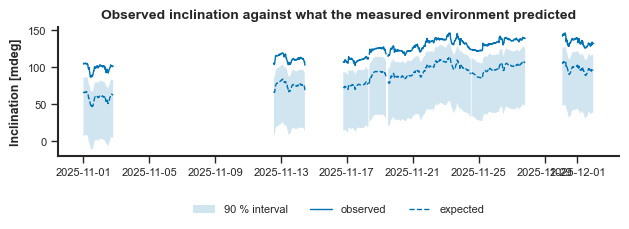

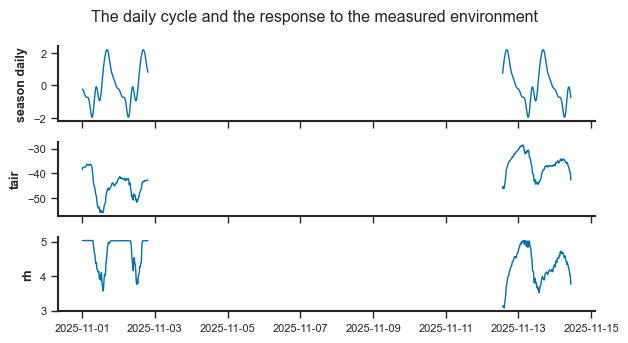

In [14]:
# One month of the evaluation period, drawn at readable density.
view = rolling.set_index('ds').sort_index().loc[
    NOWCAST_VIEW[0]:NOWCAST_VIEW[1]]
figures.plot_prediction_band(
    view['y'], view['yhat'], view['q05'], view['q95'], freq=MODEL_FREQ_A,
    title='Observed inclination against what the measured environment predicted',
    save_path=str(OUTPUT_DIR), filename='NP_F07_observed_vs_expected')

# The two interpretable components on their own axes: the daily cycle the model
# fitted, and the response it attributes to the measured environment. These come
# from the attribution fit, which is the one that claims to say what the record
# is made of.
figures.plot_decomposition_stack(
    components_a.loc[COMPONENT_VIEW[0]:COMPONENT_VIEW[1]],
    columns=['season_daily', 'future_regressor_tair', 'future_regressor_rh'],
    freq=MODEL_FREQ_A,
    title='The daily cycle and the response to the measured environment',
    save_path=str(OUTPUT_DIR), filename='NP_F06_daily_cycle_and_response')
plt.show()

### 6b · Do the components survive being re-estimated?

A component estimated once is an assertion; one that survives being
re-estimated on disjoint stretches of the record is a finding. The attribution
model is refitted on each chronological third of the training period and its
two interpretable quantities — the trend slope and the air-temperature gain —
are compared across them. A gain that changes sign between thirds, or a slope
that varies by more than its own magnitude, is reported as instability rather
than averaged away.

In [15]:
stability_rows = []
thirds = np.array_split(train_a.index.unique(), 3)
for number, block in enumerate(thirds, 1):
    part = train_a.loc[block[0]:block[-1]]
    if part['segment_id'].nunique() < 2:
        continue
    model_part, _ = prediction.neuralprophet_backtest(
        part, part, regressors=PREDICTOR_COLUMNS, task='nowcast',
        n_lags=MODEL_A_LAGS, epochs=MODEL_A_EPOCHS, yearly=MODEL_A_YEARLY,
        quantiles=(), seed=MODEL_A_SEED, growth=MODEL_A_GROWTH,
        changepoints=prediction.covered_changepoints(
            part.index, max(2, MODEL_A_CHANGEPOINTS // 3)),
        freq=MODEL_FREQ_A)
    parts = prediction.decompose_components(
        model_part, part, regressors=PREDICTOR_COLUMNS)
    paired_part = pd.concat(
        [parts['future_regressor_tair'], part['tair']], axis=1).dropna()
    paired_part.columns = ['contribution', 'tair']
    elapsed_days = ((parts.index - parts.index[0])
                    / pd.Timedelta(days=1)).to_numpy()
    stability_rows.append({
        'block': f'third {number}',
        'start': part.index.min(),
        'end': part.index.max(),
        'tair_gain_mdeg_per_degC': float(
            np.polyfit(paired_part['tair'], paired_part['contribution'], 1)[0]),
        'trend_mdeg_per_year': float(
            np.polyfit(elapsed_days, parts['trend'].to_numpy(), 1)[0] * 365.0),
    })

stability = pd.DataFrame(stability_rows)
display(stability)
stability.to_csv(OUTPUT_DIR / 'NP_16_component_stability.csv', index=False)

signs = np.sign(stability['tair_gain_mdeg_per_degC'])
print('Thermal gain keeps its sign across thirds:', bool(signs.nunique() == 1))

INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.083% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 98.667% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 99.115% of the data.


...

INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


INFO - (NP.df_utils._infer_frequency) - Major frequency 20min corresponds to 97.143% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 20min


,block,start,end,tair_gain_mdeg_per_degC,trend_mdeg_per_year
0,third 1,2023-06-21 12:00:00,2024-03-05 07:00:00,-2.470629,38.638698
1,third 2,2024-03-05 07:20:00,2025-02-27 10:40:00,-2.326066,4.791816
2,third 3,2025-02-27 11:20:00,2025-09-01 23:40:00,-2.392210,45.460495


Thermal gain keeps its sign across thirds: True
